# Manual Capability Analysis

This notebook will be used to visualize the activations and trace through the internals of GPT-2 small from the inference for some small, select samples. We will extract and visualize the following metrics:
- Attention patterns 
- Attention output
- Attention weights
- Per head residual stream contribution

This notebook will not perform the actual circuit tracing and mechanistic analysis, but instead will provide the visuals needed for it.

In [41]:
# Set project root
import sys
sys.path.append("/Users/benjawesome/coding/greater-than-cap-analysis")

In [42]:
# Imports...

# Transformer lens and GPT2-Small
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2-small")

# Import our prompt generation script and create 50 prompts
from data.greater_than_prompt_generation import generateDataset

prompts_50 = generateDataset(50)

import matplotlib.pyplot as plt

Loaded pretrained model gpt2-small into HookedTransformer


In [52]:
# Loop through the prompts and check accuracy

correct = 0
count = 0

for pair in prompts_50:
    # Extract prompt and number
    prompt = pair[0]
    num = pair[1]

    # Tokenize and extract logits
    tokens = model.to_tokens(prompt)
    logits = model(tokens)

    # Print model's prediction
    prediction = model.to_string(logits[0, -1, :].argmax(dim=-1))
    print(prediction)
    prediction = int(prediction)

    # Log accuracy
    if (prediction > num):
        correct += 1

    count += 1

print("The model correctly predicted " + str(correct) + " out of " + str(count) + " prompts.")

28
28
71
67
49
94
94
12
01
28
51
28
76
94
20
85
64
94
19
76
33
76
36
97
45
94
67
94
82
91
21
55
92
67
56
53
94
36
46
78
75
67
45
67
94
67
77
18
28
94
The model correctly predicted 45 out of 50 prompts.


## Logit Lens and Attention Pattern extraction

Here we extract and plot the logit lenses of all 12 layers for three select prompts. We will extract the residual stream after each layer and then project it into the vocabulary space, plotting the model's predictions at each layer to see how predictions develop.

In [10]:
# Create prompts and run them through the model

prompts = generateDataset(3)

prompt1 = prompts[0][0]
prompt2 = prompts[1][0]
prompt3 = prompts[2][0]


_, cache1 = model.run_with_cache(prompt1)
_, cache2 = model.run_with_cache(prompt2)
_, cache3 = model.run_with_cache(prompt3)

for prompt in prompts:
    print(model.generate(prompt[0], 1) + "\n")

100%|██████████| 1/1 [00:00<00:00, 27.51it/s]


The war lasted from 1842 to 1848



100%|██████████| 1/1 [00:00<00:00, 78.92it/s]


The war lasted from 1837 to 1839



100%|██████████| 1/1 [00:00<00:00, 68.72it/s]

The war lasted from 1815 to 1850



In [ ]:
# Extract attention patterns and visualize them with matplotlib

import math

attention_patterns = {
    "prompt1": [cache1["pattern", layer][0].detach().cpu() for layer in range(model.cfg.n_layers)],
    "prompt2": [cache2["pattern", layer][0].detach().cpu() for layer in range(model.cfg.n_layers)],
    "prompt3": [cache3["pattern", layer][0].detach().cpu() for layer in range(model.cfg.n_layers)],
}

def plot_attention_patterns(cache, prompt, prompt_label):
    tokens = model.to_str_tokens(prompt)
    n_heads = model.cfg.n_heads
    n_cols = 4
    n_rows = math.ceil(n_heads / n_cols)

    for layer in range(model.cfg.n_layers):
        pattern = cache["pattern", layer][0].detach().cpu()
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
        axes = axes.flatten()

        for head in range(n_heads):
            ax = axes[head]
            im = ax.imshow(pattern[head], cmap="viridis", vmin=0, vmax=pattern[head].max().item())
            ax.set_title(f"Head {head}")
            ax.set_xticks(range(len(tokens)))
            ax.set_yticks(range(len(tokens)))
            ax.set_xticklabels(tokens, rotation=90)
            ax.set_yticklabels(tokens)

        for ax in axes[n_heads:]:
            ax.axis("off")

        fig.suptitle(f"{prompt_label} | Layer {layer} attention patterns", fontsize=16)
        fig.colorbar(im, ax=axes.tolist(), shrink=0.7)
        plt.tight_layout()
        plt.show()

plot_attention_patterns(cache1, prompt1, "Prompt 1")
plot_attention_patterns(cache2, prompt2, "Prompt 2")
plot_attention_patterns(cache3, prompt3, "Prompt 3")


In [ ]:
# Extract the IDs of all of the numbers 01 to 99

import torch

candidate_labels = []
token_ids = []

for i in range(1, 100):
    num = f"{i:02d}"
    candidate_labels.append(num)

    # We want a clean vocab index for each two-digit completion.
    token_id = model.to_tokens(num, prepend_bos=False).squeeze(0)
    if token_id.numel() != 1:
        raise ValueError(f"{num} does not map to a single GPT-2 token.")

    token_ids.append(int(token_id.item()))

token_id_tensor = torch.tensor(token_ids, device=model.cfg.device)

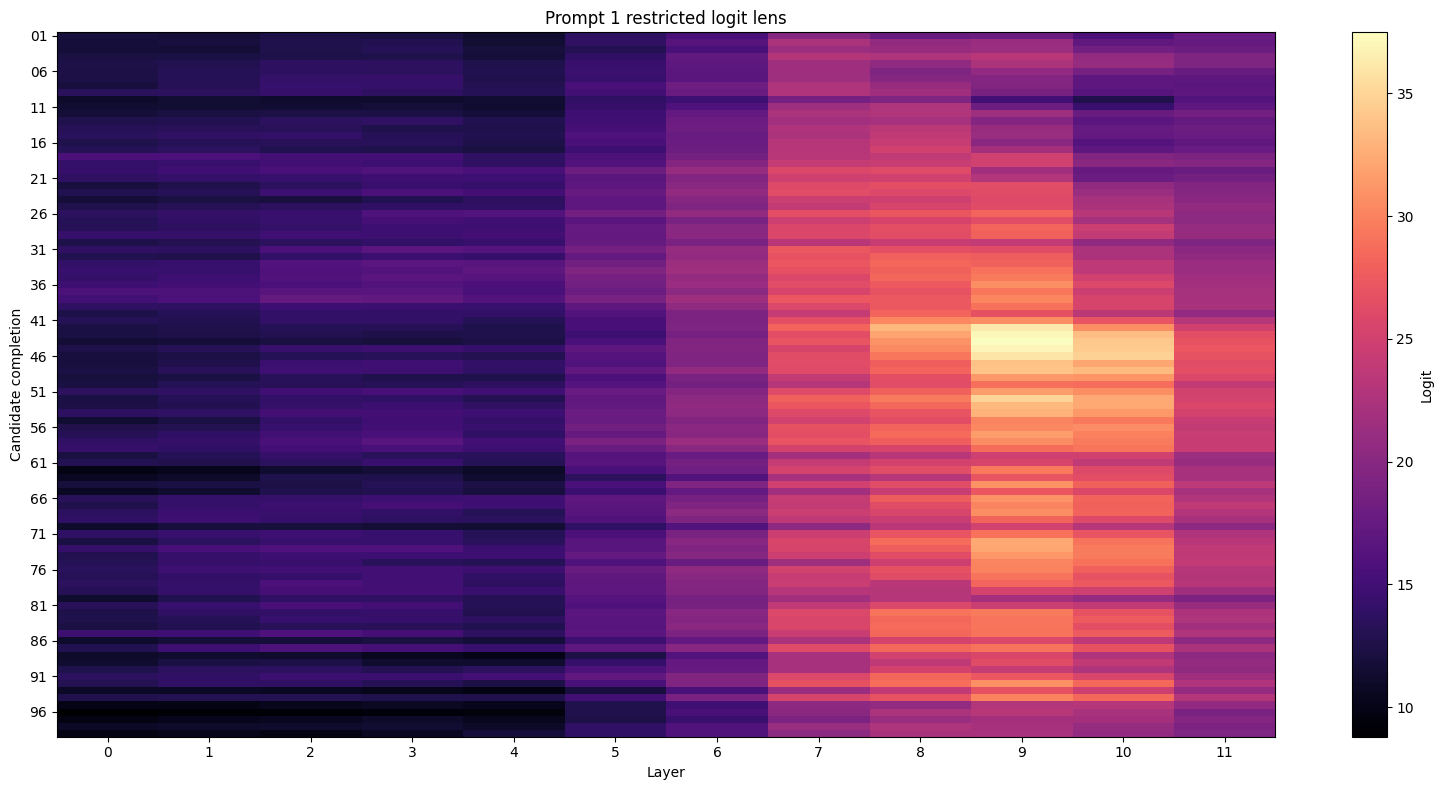

The war lasted from 1842 to 18
Top candidate per layer:
['37', '37', '38', '38', '34', '34', '38', '42', '42', '44', '46', '45']


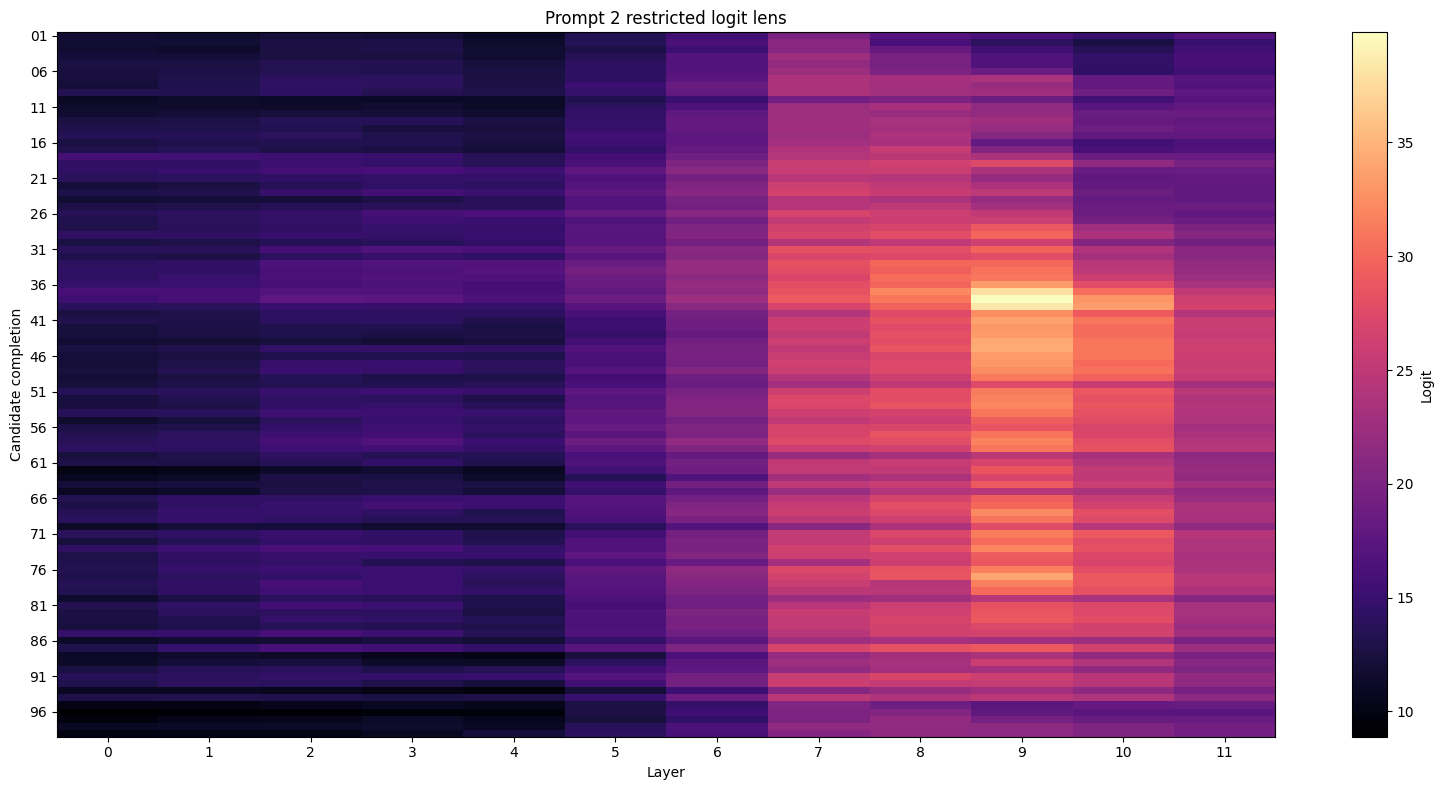

The war lasted from 1837 to 18
Top candidate per layer:
['37', '37', '38', '38', '34', '34', '38', '38', '37', '38', '39', '39']


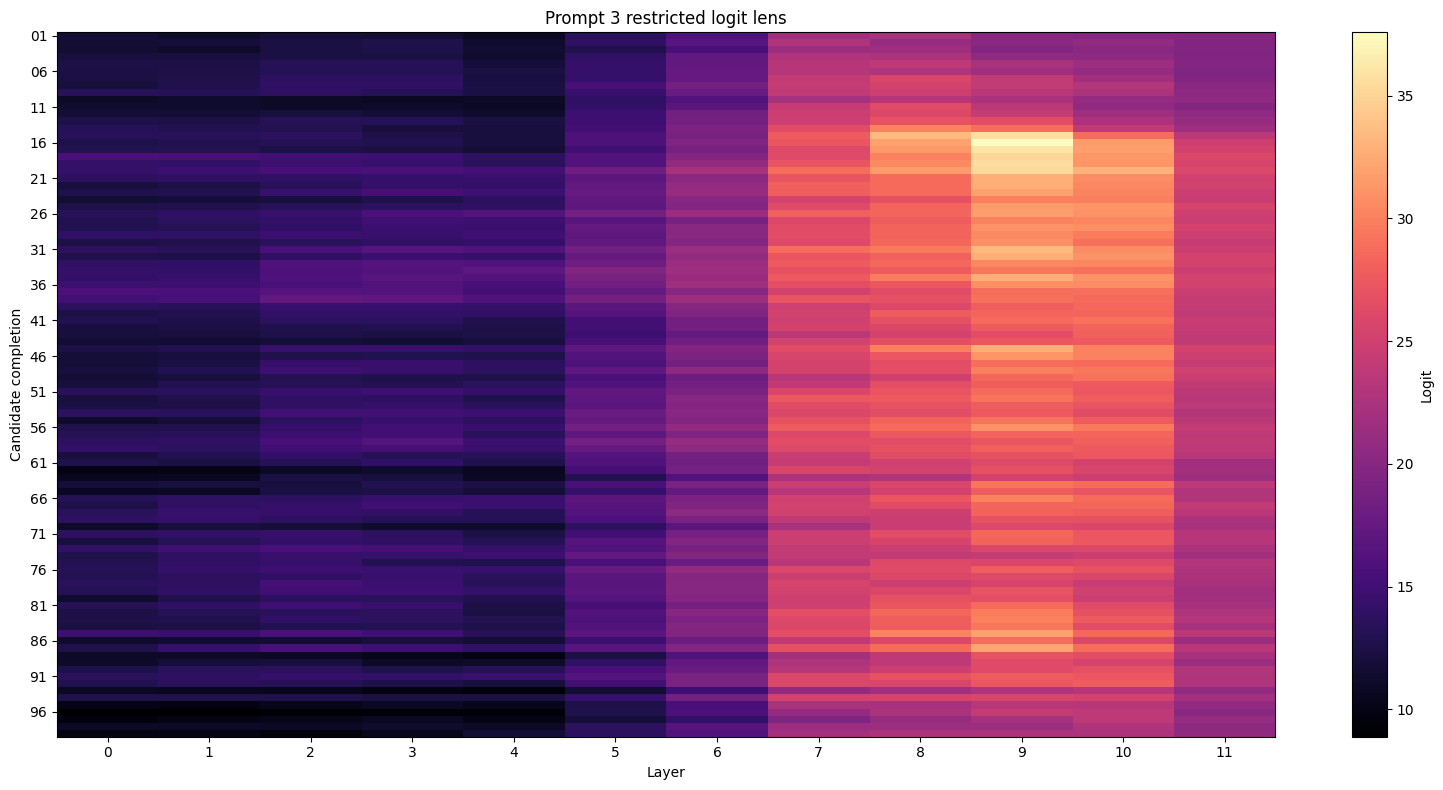

The war lasted from 1815 to 18
Top candidate per layer:
['37', '37', '38', '38', '34', '34', '20', '20', '15', '16', '20', '20']


In [15]:
# Project each layer's residual stream through GPT-2's final unembedding matrix

def compute_restricted_logit_lens(cache):
    layer_logits = []

    for layer in range(model.cfg.n_layers):
        resid_post = cache["resid_post", layer][:, -1, :]

        # A proper logit lens applies ln_final before the unembedding projection.
        normalized_resid = model.ln_final(resid_post)
        logits = normalized_resid @ model.W_U[:, token_id_tensor]

        if model.b_U is not None:
            logits = logits + model.b_U[token_id_tensor]

        layer_logits.append(logits.squeeze(0).detach().cpu())

    return torch.stack(layer_logits)

logit_lens1 = compute_restricted_logit_lens(cache1)
logit_lens2 = compute_restricted_logit_lens(cache2)
logit_lens3 = compute_restricted_logit_lens(cache3)

def plot_restricted_logit_lens(logit_lens, prompt, prompt_label):
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(logit_lens.T, aspect="auto", cmap="magma")

    ax.set_title(f"{prompt_label} restricted logit lens")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Candidate completion")
    ax.set_xticks(range(model.cfg.n_layers))

    y_ticks = list(range(0, len(candidate_labels), 5))
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([candidate_labels[i] for i in y_ticks])

    target_suffix = prompt[-2:]

    fig.colorbar(im, ax=ax, label="Logit")
    plt.tight_layout()
    plt.show()

    top_candidates = logit_lens.argmax(dim=-1).tolist()
    print(prompt)
    print("Top candidate per layer:")
    print([candidate_labels[idx] for idx in top_candidates])

plot_restricted_logit_lens(logit_lens1, prompt1, "Prompt 1")
plot_restricted_logit_lens(logit_lens2, prompt2, "Prompt 2")
plot_restricted_logit_lens(logit_lens3, prompt3, "Prompt 3")

Text(0, 0.5, 'Predicted year')

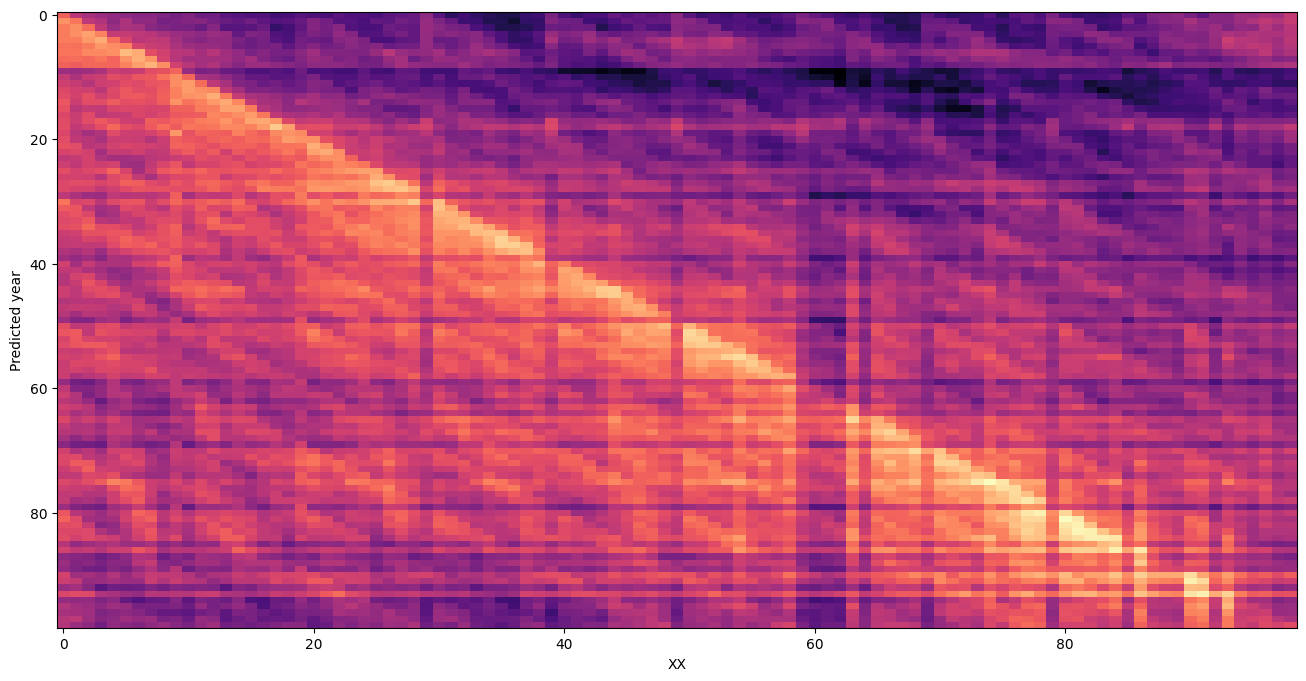

In [35]:
# Now we plot the logit lens for all of the prompts at once

logit_lenses = []

for i in range(1, 100):
    # Create prompt
    num = f"{i:02d}"
    prompt = "The war lasted from 18" + num + " to 18"

    _, cache = model.run_with_cache(prompt)

    # Extract residual stream post attention layer & compute logits
    resid_post = cache["resid_post", 9][:, -1, :]
    normalized_resid = model.ln_final(resid_post)
    logits = normalized_resid @ model.W_U[:, token_id_tensor]

    # Append logits
    logit_lenses.append(logits.squeeze(0).detach().cpu())

logit_lenses = torch.stack(logit_lenses)

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(logit_lenses.T, aspect="auto", cmap="magma")

plt.xlabel("XX")
plt.ylabel("Predicted year")

In [ ]:
# Loop through every attention head and ablate (zero) to measure change in accuracy

accuracies = []

def calculate_ablated_accuracy(prompts, layer_to_ablate, head_index_to_ablate):
    # Initialize
    correct = 0
    count = 0

    def head_ablation_hook(value, hook):
        value[:, :, head_index_to_ablate, :] = 0
        return value

    for pair in prompts:
        # Extract prompt and number
        prompt = pair[0]
        num = pair[1]

        # Tokenize and extract logits
        tokens = model.to_tokens(prompt)
        
        logits = model.run_with_hooks(tokens, return_type='logits', 
                        fwd_hooks=[(
                            f"blocks.{layer_to_ablate}.attn.hook_v",
                            head_ablation_hook
                        )])
        
        # Get model prediction
        prediction = logits[0, -1].argmax()
        try:
            prediction = int(model.to_string(prediction))
            if prediction > num:
                correct += 1
        except ValueError:
            pass 

        count += 1

    return count, correct

for layer in range(model.cfg.n_layers):
    for head in range(model.cfg.n_heads):
        count, correct = calculate_ablated_accuracy(prompts_50, layer, head)
        print("Layer " + str(layer) + " attention head " + str(head) + " accuracies: " + str(correct))
        accuracies.append((layer, head, correct / count))



Layer 0 attention head 0 accuracies: 44
Layer 0 attention head 1 accuracies: 45
Layer 0 attention head 2 accuracies: 44
Layer 0 attention head 3 accuracies: 44
Layer 0 attention head 4 accuracies: 45
Layer 0 attention head 5 accuracies: 44
Layer 0 attention head 6 accuracies: 44
Layer 0 attention head 7 accuracies: 44
Layer 0 attention head 8 accuracies: 42
Layer 0 attention head 9 accuracies: 42
Layer 0 attention head 10 accuracies: 48
Layer 0 attention head 11 accuracies: 43
Layer 1 attention head 0 accuracies: 45
Layer 1 attention head 1 accuracies: 45
Layer 1 attention head 2 accuracies: 45
Layer 1 attention head 3 accuracies: 44
Layer 1 attention head 4 accuracies: 45
Layer 1 attention head 5 accuracies: 45
Layer 1 attention head 6 accuracies: 44
Layer 1 attention head 7 accuracies: 44
Layer 1 attention head 8 accuracies: 45
Layer 1 attention head 9 accuracies: 42
Layer 1 attention head 10 accuracies: 44
Layer 1 attention head 11 accuracies: 42
Layer 2 attention head 0 accuracies: